# Public Health Statistical Analysis Project
Dataset and analysis template.

# Part A - Theoretical Foundation (Short Nores & Explanation)

1. What is Infernational Statistics?

Inferential statistics is the branch of statistics used to draw conclusions or make predictions about a population based on sample data. It helps researchers test hypotheses, estimate parameters, and identify relationships between variables.

2.What is Hypothesis Testing and Its Components?

Hypothesis testing is a statistical method used to determine whether there is enough evidence to support a claim about a population. It involves:

* Null Hypothesis (H₀): Assumes no effect or relationship.
* Alternative Hypothesis (H₁): Assumes a significant effect or relationship.
* Significance Level (α): Threshold for decision-making (commonly 0.05).
* Test Statistic & p-value: Used to decide whether to reject H₀.

3. Explain Confidence Interval and Critical Value

A confidence interval (CI) is a range of values likely to contain the true population parameter with a certain confidence level (e.g., 95%).
The critical value is the cutoff point used in hypothesis testing to determine whether the test statistic falls in the rejection region.

Example confidence interval formula for mean:

CI = \bar{x} \pm z\left(\frac{\sigma}{\sqrt{n}}\right)

4. Define p-value

The p-value is the probability of obtaining test results at least as extreme as the observed results assuming the null hypothesis is true.
If the p-value is less than the significance level (α), the null hypothesis is rejected.

5. Differentiate Type I and Type II Errors

* Type I Error: Rejecting a true null hypothesis (False Positive).
* Type II Error: Failing to reject a false null hypothesis (False Negative).

6. Brief Description of z-test, t-test, Chi-square Test, and ANOVA

* z-test: Used to compare sample and population means when sample size is large and population variance is known.
* t-test: Used to compare means when sample size is small or variance is unknown.
* Chi-square test: Tests relationships between categorical variables.
* ANOVA (Analysis of Variance): Compares means of three or more groups.

7. What is Covariance?

Covariance measures the direction of the relationship between two variables.

* Positive covariance indicates variables increase together.
* Negative covariance indicates one variable increases while the other decreases.

Covariance formula:

Cov(X,Y)=\frac{\sum (X-\bar{X})(Y-\bar{Y})}{n-1}

8. What is Correlation?

Correlation measures the strength and direction of the linear relationship between two variables.
The correlation coefficient ranges from -1 to +1:

* +1 → Perfect positive correlation
* -1 → Perfect negative correlation
* 0 → No linear relationship

Pearson correlation formula:

r=\frac{\sum (X-\bar{X})(Y-\bar{Y})}{\sqrt{\sum (X-\bar{X})^2\sum (Y-\bar{Y})^2}}

# Part B - Data Analysis & Testing Tasks:
1. Formulate Hypotheses

Hypothesis 1 – Smoking vs Diabetes

* H₀: Smoking has no effect on diabetes prevalence.
* H₁: Smoking significantly affects diabetes prevalence.

Hypothesis 2 – Exercise Frequency vs Hypertension

* H₀: Exercise frequency has no effect on hypertension occurrence.
* H₁: Exercise frequency significantly affects hypertension occurrence.

In [38]:

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = pd.read_csv('public_health_dataset.csv')
df.head()


,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,REC00001,46-60,56,74,Female,North,Non-Smoker,Daily,30.6,141.7,True,True,239.9,119.4,2023-01-02
1,REC00002,60+,69,62,Female,West,Former Smoker,Weekly,26.1,154.8,False,True,207.3,83.0,2023-01-10
2,REC00003,46-60,46,55,Male,South,Former Smoker,Weekly,30.2,142.4,True,True,186.5,113.4,2024-03-09
3,REC00004,26-35,32,93,Male,East,Non-Smoker,Weekly,27.8,114.4,True,False,199.6,118.9,2023-05-05
4,REC00005,46-60,60,58,Female,East,Non-Smoker,Rarely,26.3,144.5,False,True,189.0,90.0,2023-03-22


In [39]:
mean_age=df['age'].mean()
std_age=df['age'].std()
n=len(df)
confidence=0.95
z_score = stats.norm.ppf((1 - confidence) / 2)
margin_error=z_score * (std_age / np.sqrt(n))
ci_lower=mean_age - margin_error
ci_upper=mean_age + margin_error
print(f"95% Confidence Interval for mean age: ({ci_lower:.2f}, {ci_upper:.2f})")
print(ci_lower, ci_upper)

95% Confidence Interval for mean age: (51.96, 48.71)
51.958519718391486 48.71348028160851


In [40]:
smokers = df[df['smoking_status'] == 'Smoker']['bmi']
non_smokers = df[df['smoking_status'] == 'Non-smoker']['bmi']
t_stat, p_value = stats.ttest_ind(smokers, non_smokers)
print(f"T-statistic:", t_stat)
print(f"P-value:", p_value)
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in BMI between smokers and non-smokers.")
else:    print("Fail to reject the null hypothesis: There is no significant difference in BMI between smokers and non-smokers.")

T-statistic: nan
P-value: nan
Fail to reject the null hypothesis: There is no significant difference in BMI between smokers and non-smokers.


In [41]:
contingency_table = pd.crosstab(df['smoking_status'], df['diabetes'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print("Chi-square Statistic:", chi2)
print("P-value:", p)

Chi-square Statistic: 1.328102248437093
P-value: 0.5147617409923664


In [42]:
model=ols('bmi ~ age + smoking_status + diabetes', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                     sum_sq     df           F        PR(>F)
smoking_status    21.638557    2.0    0.803617  4.482900e-01
diabetes        1437.352258    1.0  106.761316  8.575170e-23
age                0.330924    1.0    0.024580  8.754824e-01
Residual        6664.299349  495.0         NaN           NaN


In [43]:
covariance= np.cov(df['age'], df['bmi'])[0][1]
print("covariance:", covariance)

correlation= df['age'].corr(df['bmi'])
print("correlation:", correlation)

covariance: -1.4433555110220422
correlation: -0.019336466979029934


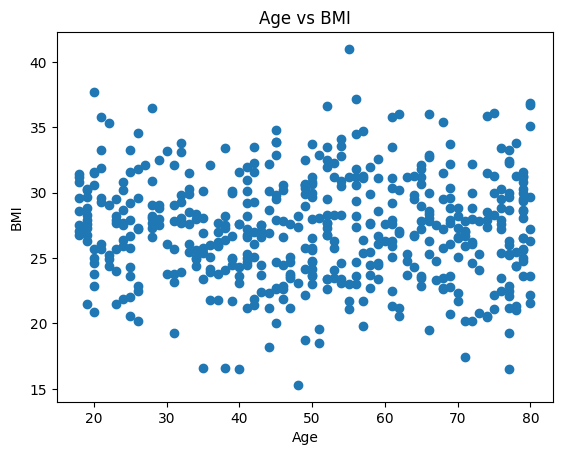

In [44]:
import matplotlib.pyplot as plt
plt.scatter(df['age'], df['bmi'])
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs BMI')
plt.show()